# Statistical Anomaly Detection System

## Notebook 03: Robust Statistical Analysis

### Purpose

This notebook investigates the presence of extreme observations and heavy-tailed behavior using robust statistical techniques.

### Objectives

- Compare classical and robust statistics
- Measure dispersion using robust methods
- Compute robust z-scores
- Identify extreme observations
- Evaluate heavy-tailed characteristics

### Expected Outcome

A robust understanding of pollutant variability and potential anomalies.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import median_abs_deviation

import os

os.makedirs("images", exist_ok=True)

In [2]:
df = pd.read_csv(
    "Air Quality Data in India.csv",
    encoding="latin1",
    low_memory=False
)

pollutants = [
    "so2",
    "no2",
    "rspm",
    "spm"
]

air_quality = df[pollutants].copy()

for col in pollutants:

    air_quality[col] = (
        air_quality[col]
        .fillna(
            air_quality[col].median()
        )
    )

air_quality.head()

,so2,no2,rspm,spm
0,4.8,17.4,84.0,181.0
1,3.1,7.0,84.0,181.0
2,6.2,28.5,84.0,181.0
3,6.3,14.7,84.0,181.0
4,4.7,7.5,84.0,181.0


## Classical vs Robust Statistics

Robust statistics are less sensitive to extreme observations than traditional measures such as the mean and standard deviation.

In [4]:
summary_stats = pd.DataFrame()

summary_stats["Mean"] = air_quality.mean()
summary_stats["Median"] = air_quality.median()
summary_stats["Std Dev"] = air_quality.std()

summary_stats["MAD"] = [
    median_abs_deviation(
        air_quality[col]
    )
    for col in pollutants
]

summary_stats

,Mean,Median,Std Dev,MAD
so2,7.732732,5.5,6.076720,1.5
no2,27.330200,29.0,13.363749,5.7
rspm,83.167192,84.0,31.044460,16.0
spm,197.299304,181.0,86.443519,51.0


In [5]:
summary_stats.round(2)

,Mean,Median,Std Dev,MAD
so2,7.73,5.5,6.08,1.5
no2,27.33,29.0,13.36,5.7
rspm,83.17,84.0,31.04,16.0
spm,197.30,181.0,86.44,51.0


In [6]:
summary_stats.round(2).to_csv(
    "robust_statistics_summary.csv"
)

## Robust Z-Score Analysis

Robust z-scores use the median and MAD instead of the mean and standard deviation.

This approach is more appropriate when distributions contain extreme observations.

In [7]:
robust_z_scores = pd.DataFrame()

for col in pollutants:

    median = air_quality[col].median()

    mad = median_abs_deviation(
        air_quality[col]
    )

    robust_z_scores[col] = (
        0.6745 *
        (air_quality[col] - median)
        / mad
    )

In [8]:
robust_z_scores.head()

,so2,no2,rspm,spm
0,-0.314767,-1.372667,0.0,0.0
1,-1.079200,-2.603333,0.0,0.0
2,0.314767,-0.059167,0.0,0.0
3,0.359733,-1.692167,0.0,0.0
4,-0.359733,-2.544167,0.0,0.0


In [9]:
anomaly_mask = (
    robust_z_scores.abs() > 3.5
)

anomaly_counts = (
    anomaly_mask.sum()
)

anomaly_counts

,0
so2,746
no2,196
rspm,106
spm,77


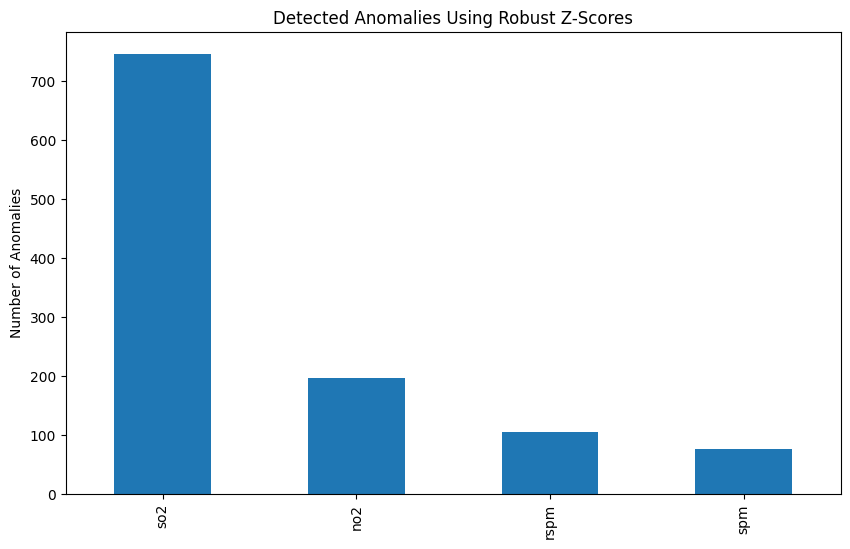

In [10]:
plt.figure(figsize=(10,6))

anomaly_counts.plot(
    kind="bar"
)

plt.title(
    "Detected Anomalies Using Robust Z-Scores"
)

plt.ylabel(
    "Number of Anomalies"
)

plt.savefig(
    "images/robust_anomaly_counts.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

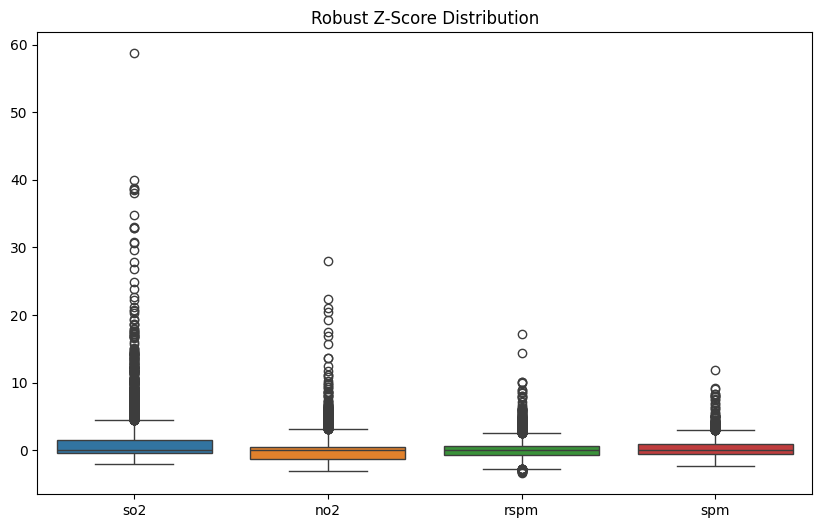

In [11]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=robust_z_scores
)

plt.title(
    "Robust Z-Score Distribution"
)

plt.savefig(
    "images/robust_zscore_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
anomaly_counts.to_csv(
    "anomaly_counts.csv"
)

## Findings

The pollutant variables exhibit substantial departures from normality and contain extreme observations.

Robust statistical measures provided a more reliable characterization of the data than traditional mean-based summaries.

The robust z-score analysis identified a considerable number of anomalous observations, supporting the need for dedicated anomaly detection techniques in subsequent analyses.